<a href="https://colab.research.google.com/github/ahmedosman2a/Service-Marketing-Assignment-/blob/main/Entrepreneurship%20and%20Innovation%20assignment%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✓ Cell 0 complete — environment ready

── Dataset summary ──────────────────────────────────
  master_eu27           27 rows × 15 cols
  d01_eibis             27 rows ×  3 cols
  d02_eurostat          27 rows ×  2 cols
  d03_barriers          12 rows ×  5 cols
  d04_desi              27 rows ×  2 cols
  d06_gii               27 rows ×  7 cols
  d07_conc              26 rows ×  3 cols
  d07_temporal          14 rows ×  2 cols
  d08_conc              23 rows ×  3 cols
  d08_temporal          14 rows ×  2 cols
  d09_eba               25 rows ×  2 cols
  d14_basel             27 rows ×  7 cols
  oecd_pubs            250 rows ×  3 cols

✓ Cell 1 complete — 13 datasets loaded

═══════════════════════════════════════════════════
DESCRIPTIVE STATISTICS — MASTER TABLE (N = 27)
═══════════════════════════════════════════════════
       eibis_genai_pct  eibis_depth_pct  eurostat_ai_pct_2024  desi_ai_pct  gii_score  reg_quality_score  gerd_pct_gdp  vc_deals_per_gdp  aml_quality  compliance_score
c

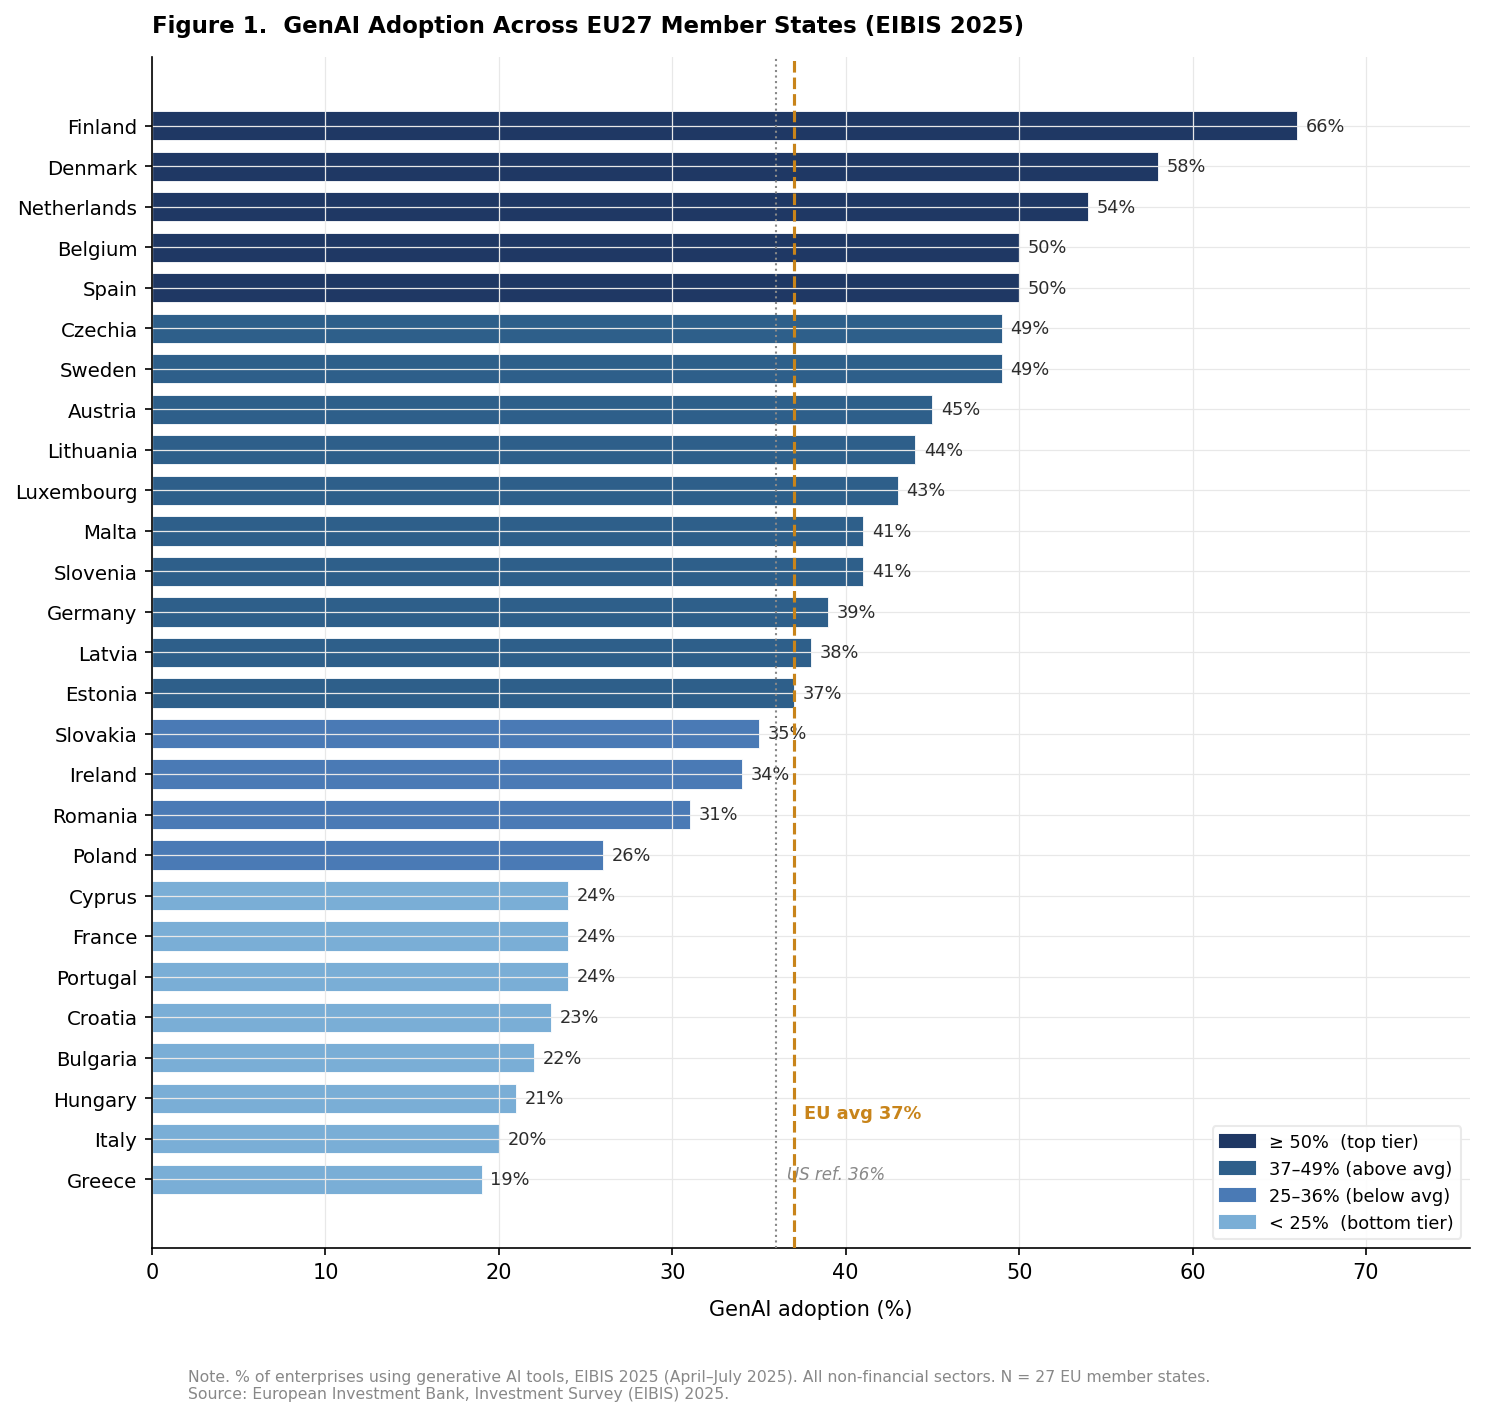

✓ Saved fig1_eibis_adoption.png


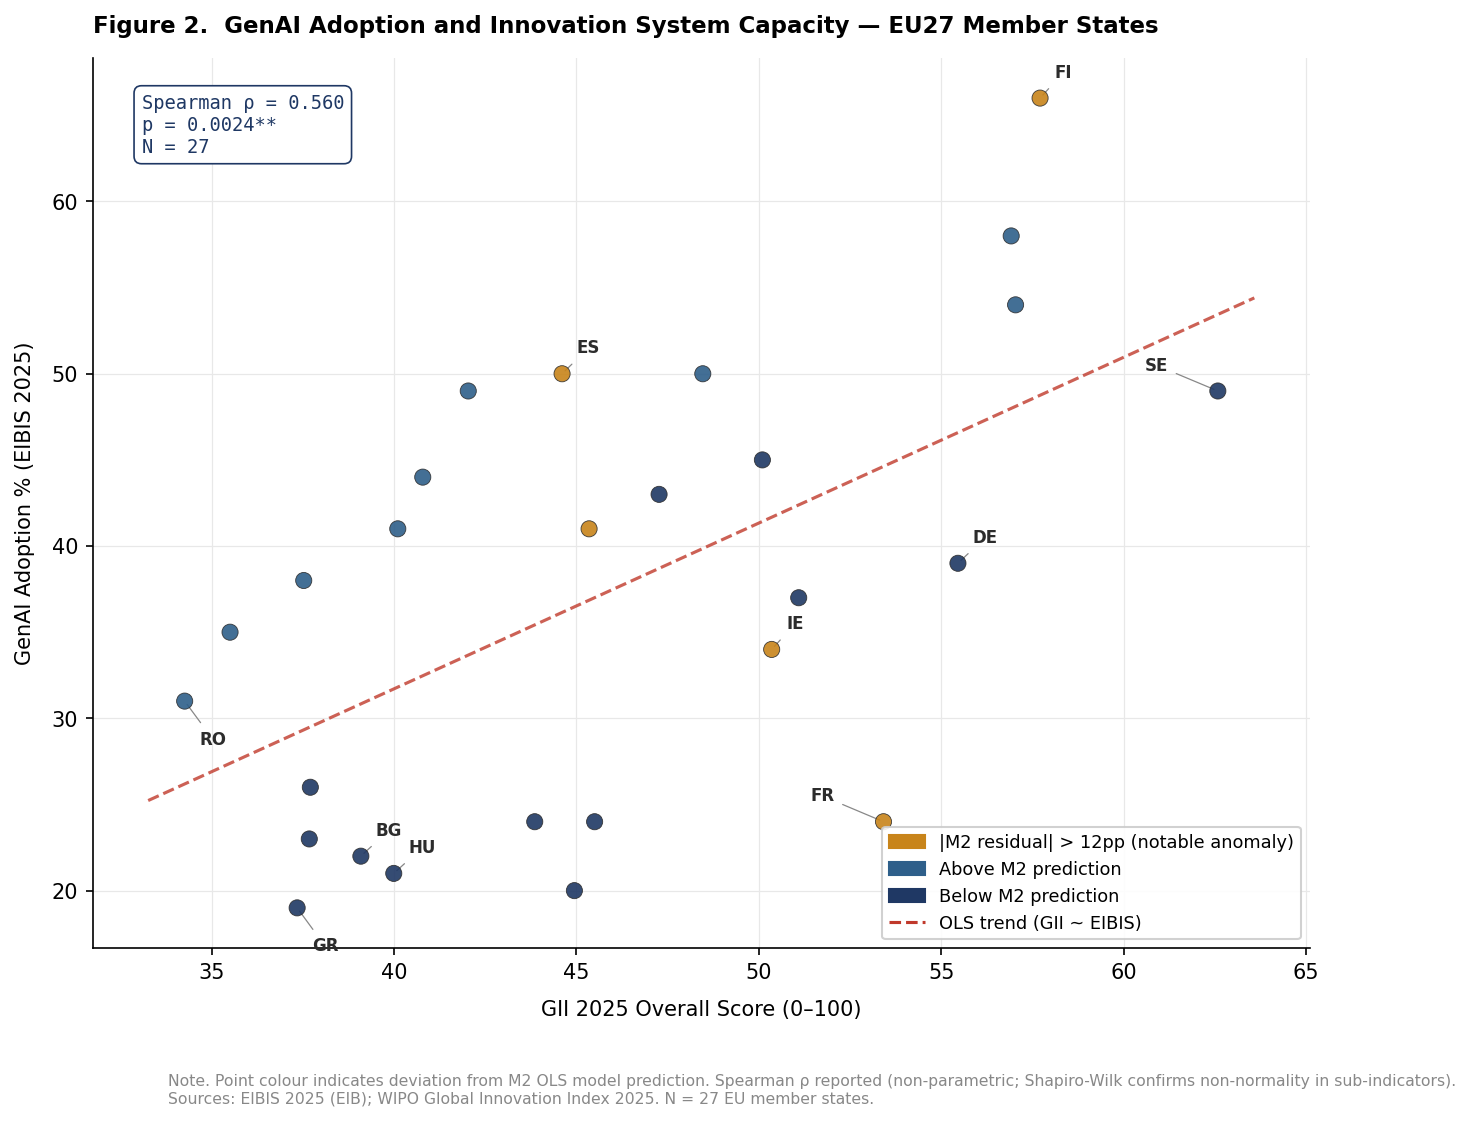

✓ Saved fig2_eibis_vs_gii.png


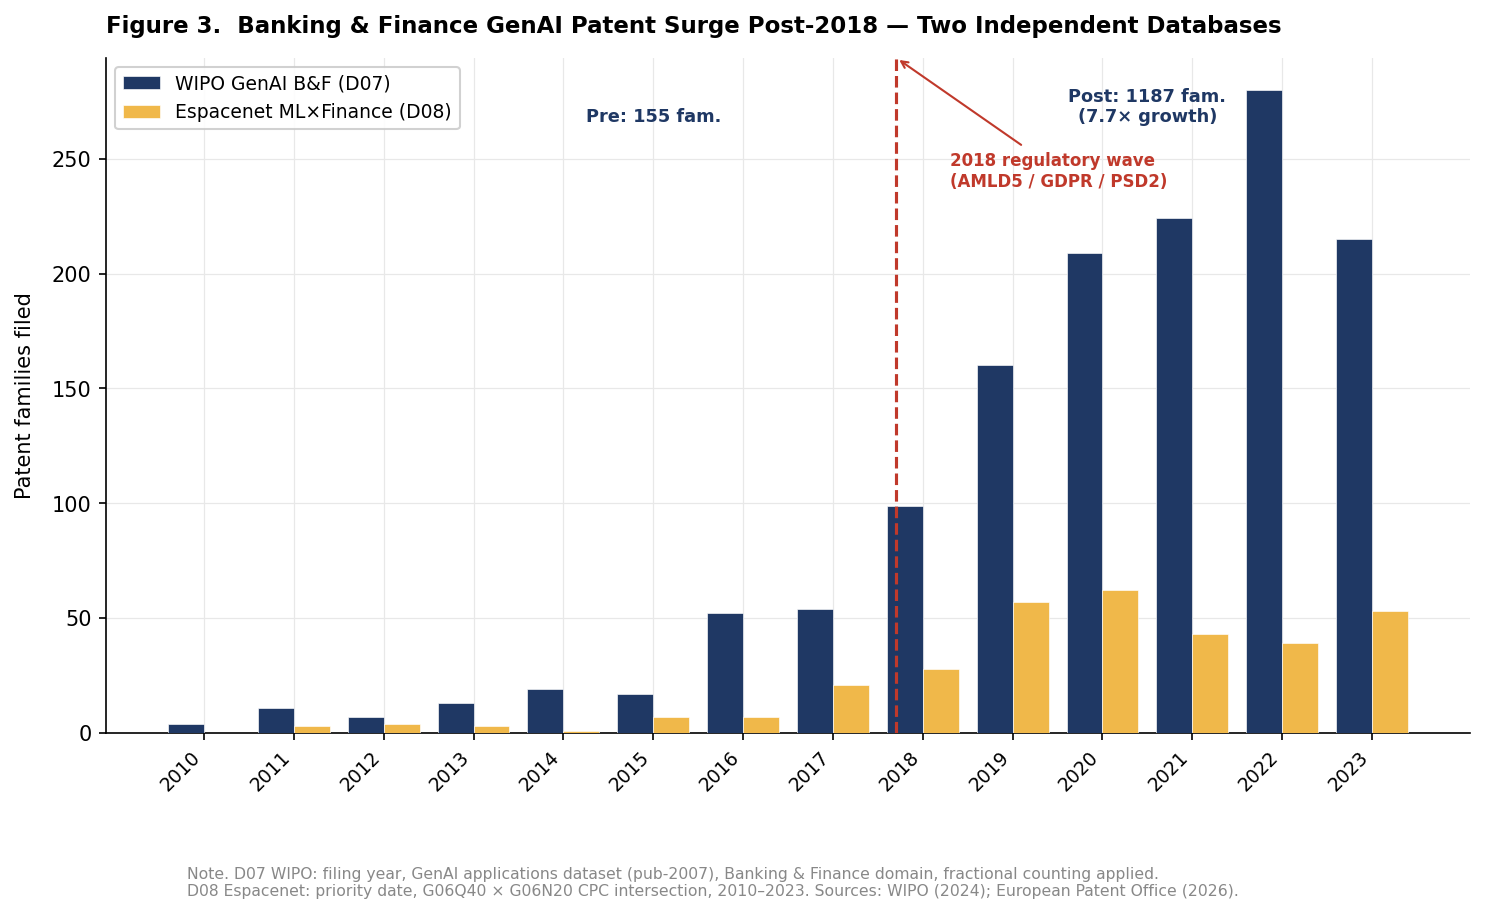

✓ Saved fig3_patent_temporal.png


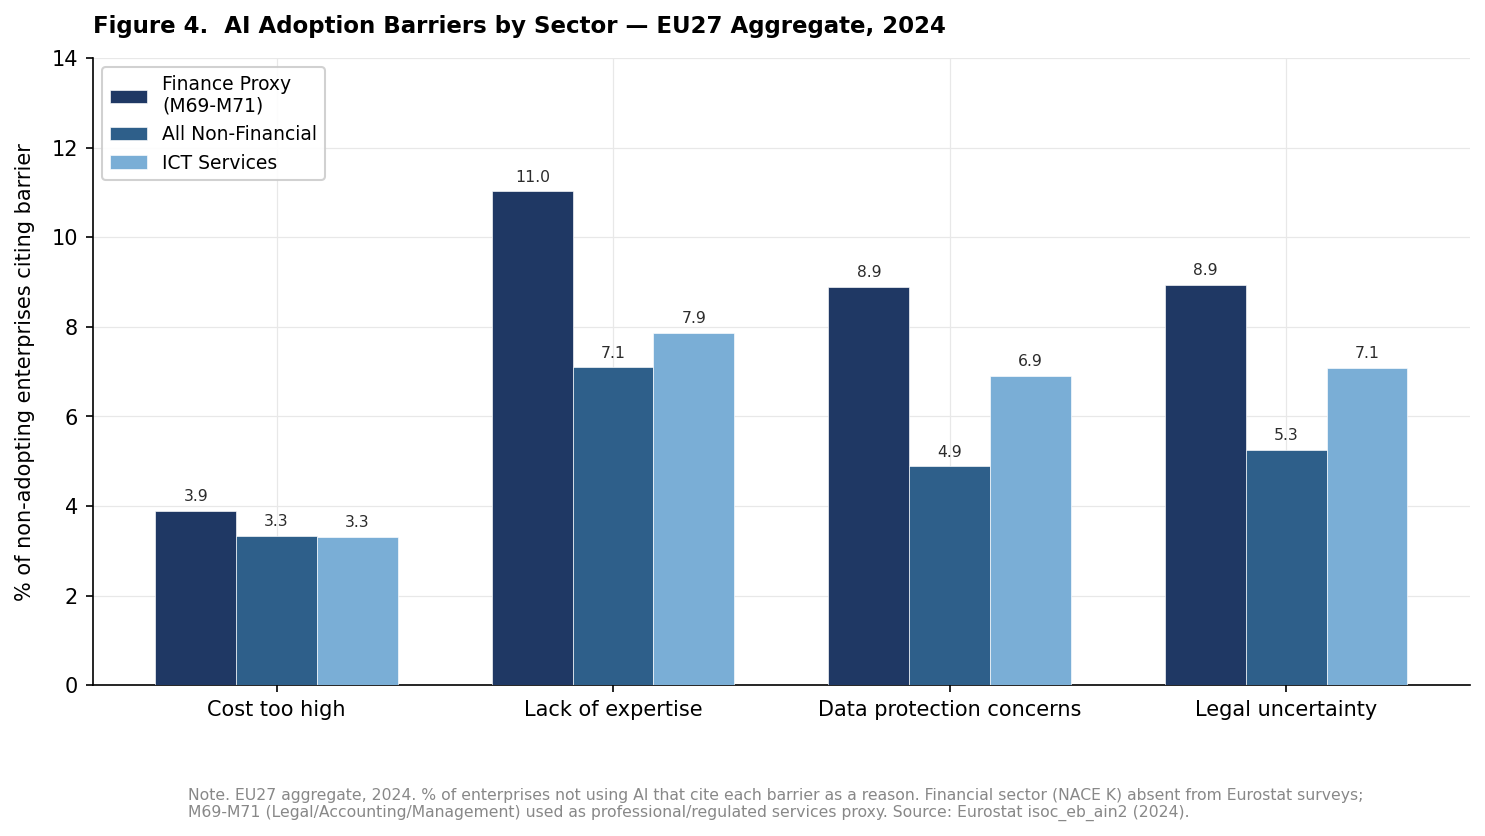

✓ Saved fig4_barriers_sector.png


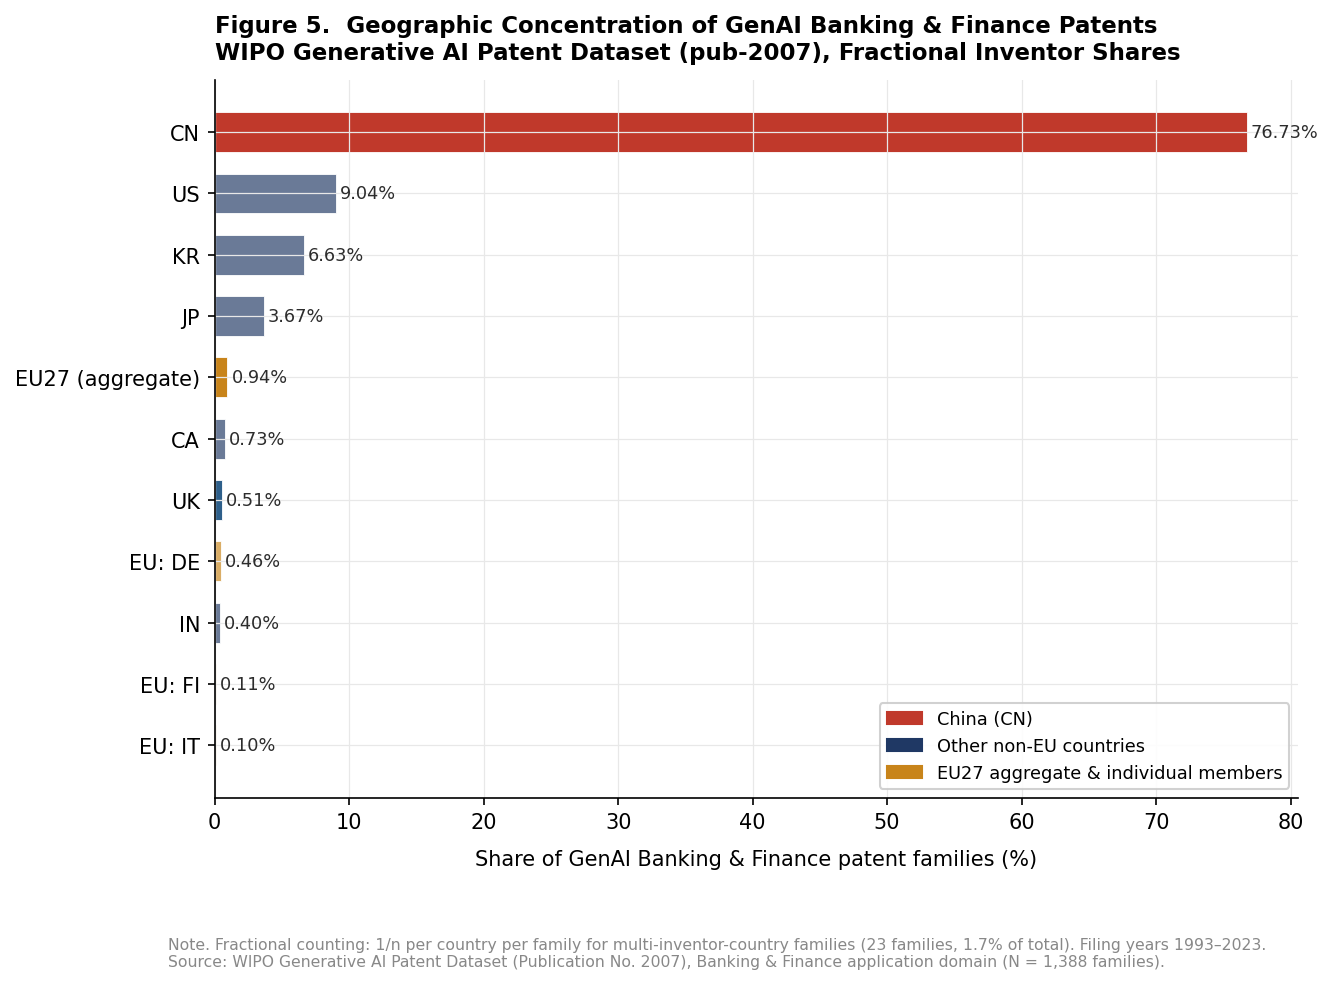

✓ Saved fig5_patent_concentration.png


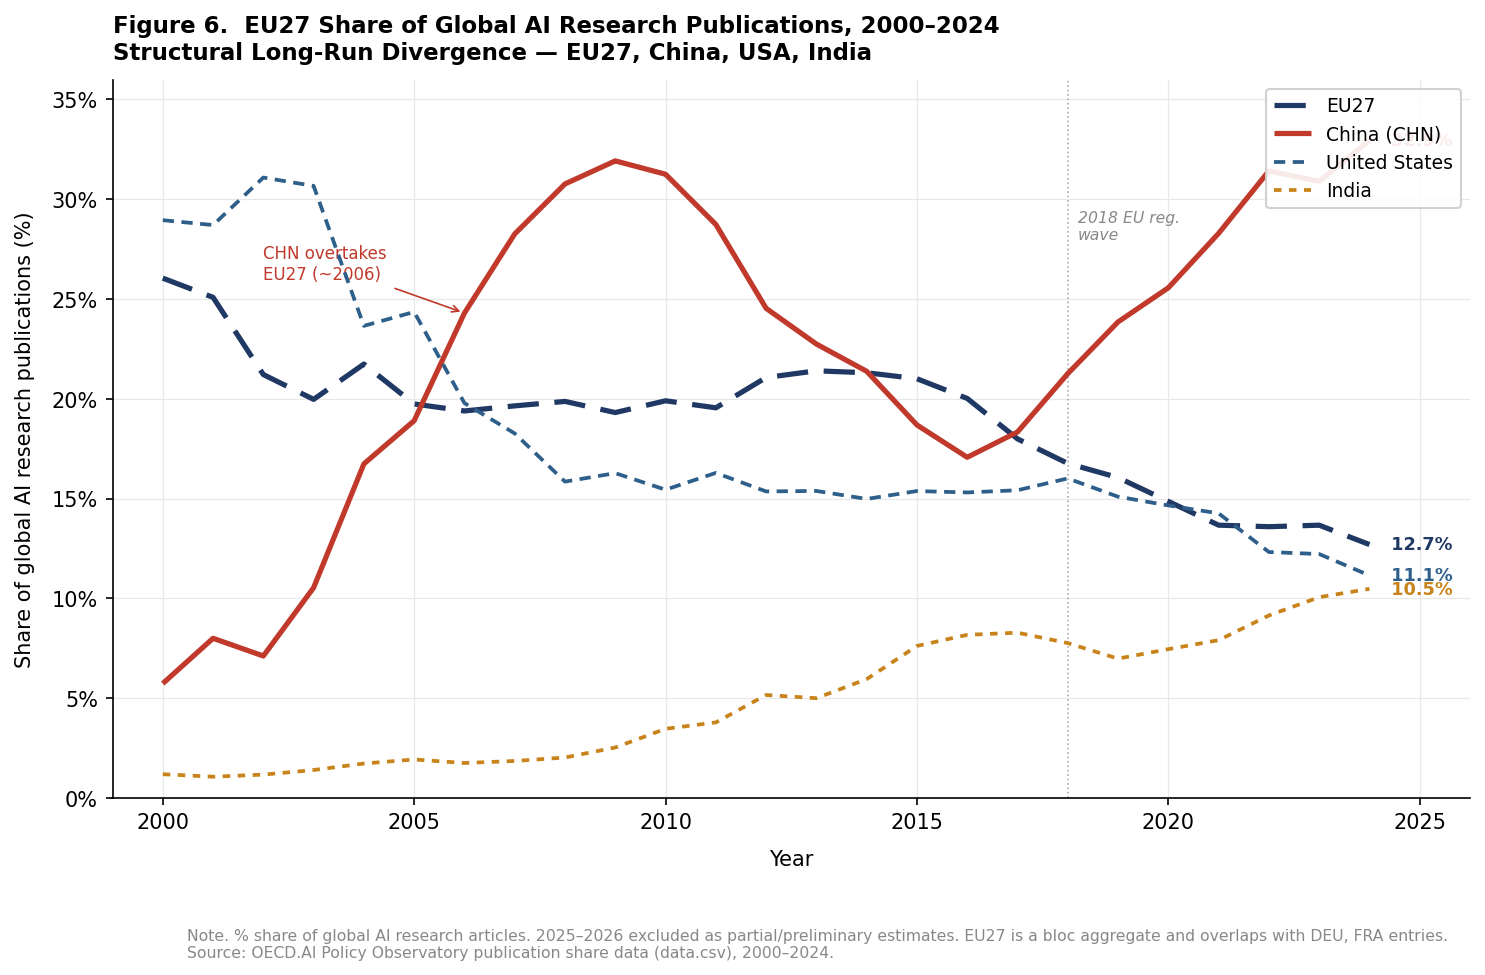

✓ Saved fig6_oecd_pubs.png


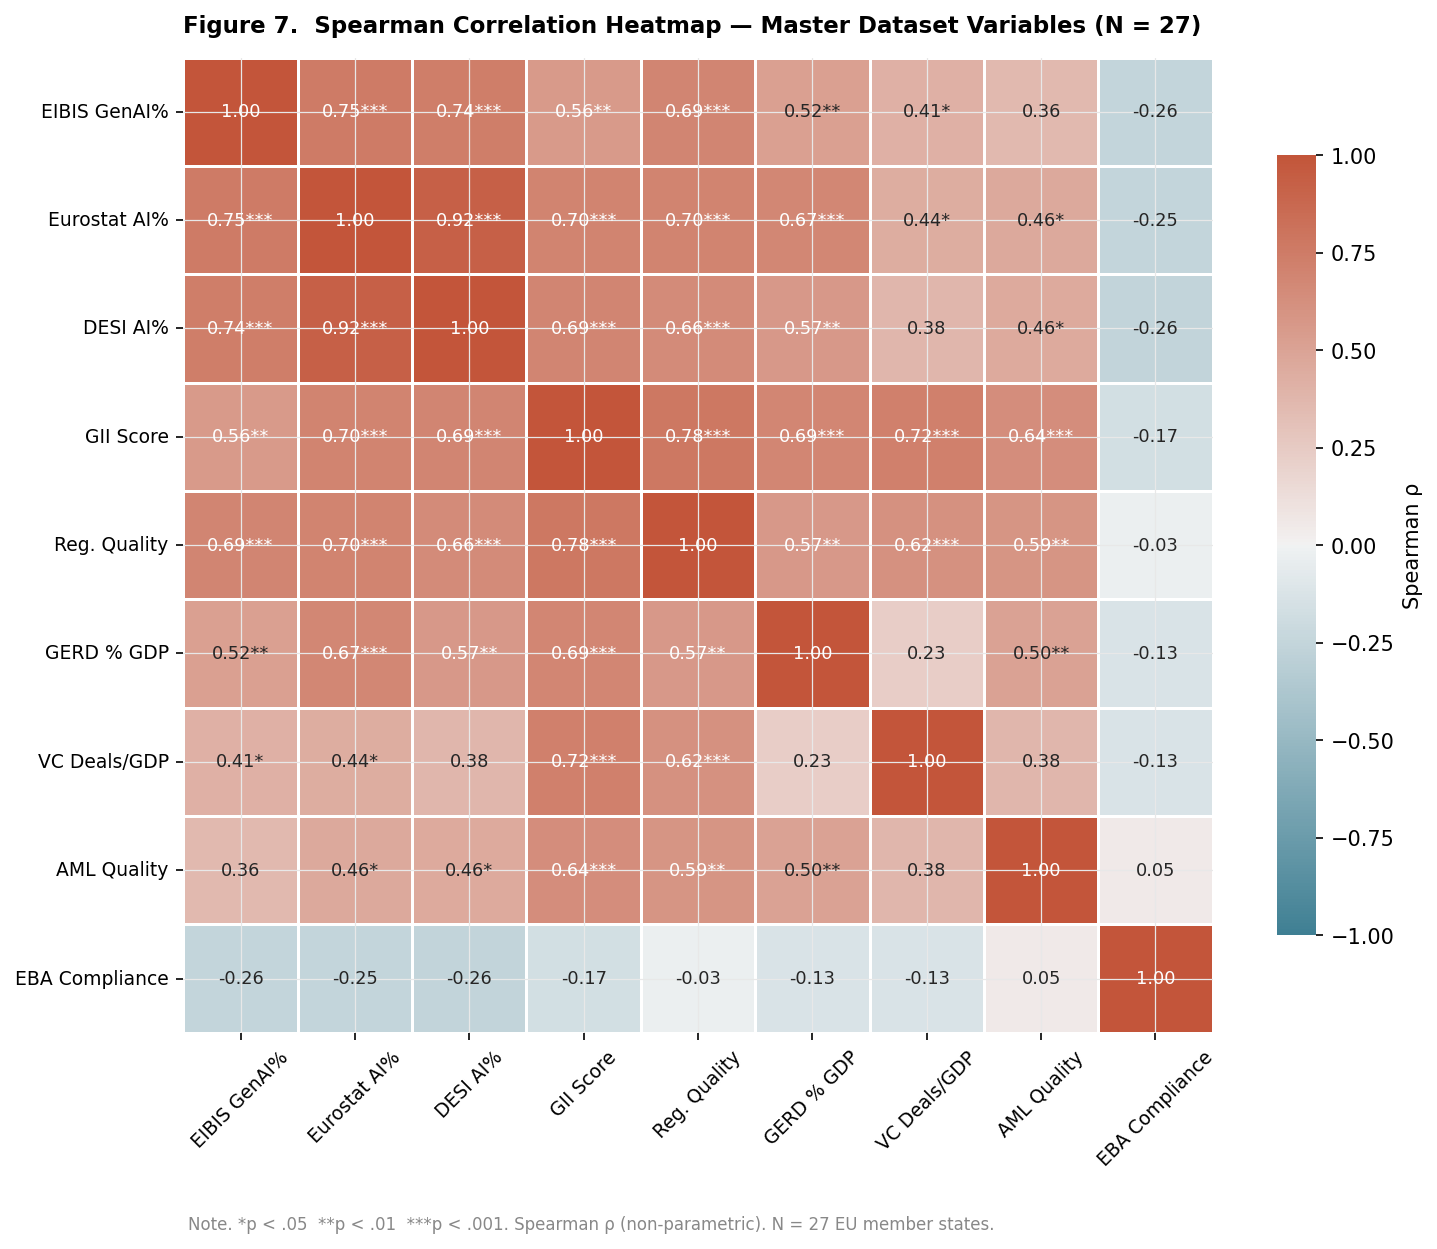

✓ Saved fig7_correlation_heatmap.png


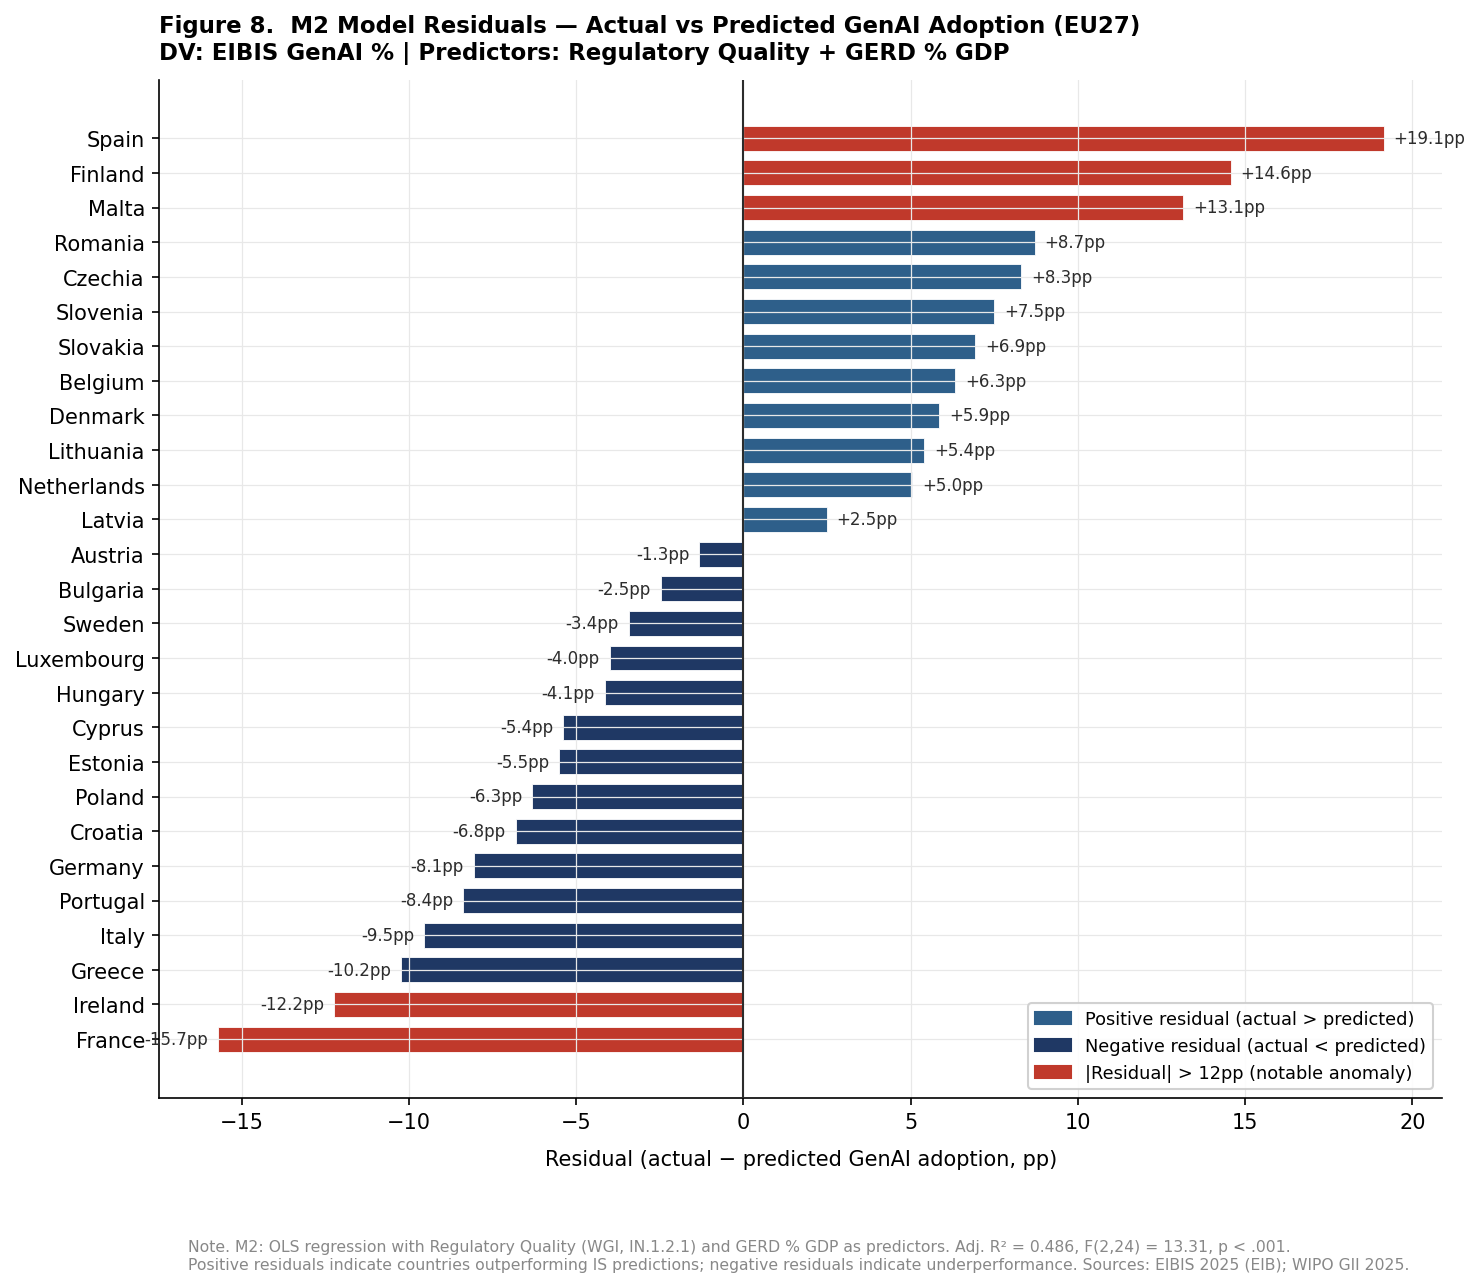

✓ Saved fig8_m2_residuals.png

── Master Table (sorted by EIBIS GenAI adoption) ───
    Country  EIBIS GenAI % (2025)  Eurostat AI % (2024)  DESI AI-only % (2024)  GII Score (2025)  GII Rank  Regulatory Quality  GERD % GDP  VC Deals / bn PPP$ GDP  AML Quality (10−mltf)  EBA GL Compliance (0–2)  M2 Predicted GenAI %  M2 Residual (pp)
    Finland                  66.0                 24.37                  15.10             57.71       7.0                1.77        3.09                    0.76                   6.36                        2                 51.43             14.57
    Denmark                  58.0                 27.58                  15.17             56.91       9.0                1.84        2.99                    0.67                   5.80                        0                 52.14              5.86
Netherlands                  54.0                 23.06                  14.10             57.04       8.0                1.79        2.23                    0.41 

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  Macro-Level AI Innovation Capacity in European Financial Services      ║
# ║  Full Reproduction Script — Tables, Statistics & Charts                 ║
# ║  Course 41647 Innovation & Entrepreneurship | Universidade do Minho     ║
# ║  Ahmed H. Osman | April 2026                                            ║
# ╚══════════════════════════════════════════════════════════════════════════╝
#
# USAGE IN GOOGLE COLAB
# ─────────────────────
# Step 1: Upload all CSV files to Colab (drag-and-drop into the Files panel)
#         OR mount Google Drive and update DATA_DIR below.
# Step 2: Run Cell 0 (install / imports).
# Step 3: Run Cell 1 (load data) — verify the printed shape summary.
# Step 4: Run any subsequent cells in order or individually.
#
# REQUIRED FILES (13 CSVs)
# ─────────────────────────
#   master_eu27.csv            clean_d07_country_conc.csv
#   clean_d01_eibis.csv        clean_d07_temporal.csv
#   clean_d02_eurostat.csv     clean_d08_country_conc.csv
#   clean_d03_barriers.csv     clean_d08_temporal.csv
#   clean_d04_desi_ai.csv      clean_d09_eba.csv
#   clean_d06_gii.csv          clean_d14_basel.csv
#                              clean_oecd_pubs.csv
#
# ── Change this if your files live elsewhere ─────────────────────────────
DATA_DIR = "/content/"          # default Colab upload directory
OUT_DIR  = "/content/outputs/"  # charts and tables will be saved here


# ══════════════════════════════════════════════════════════════════════════
# CELL 0 — Install dependencies & configure environment
# ══════════════════════════════════════════════════════════════════════════
# Run this cell first (takes ~30 seconds on a fresh Colab runtime)

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["scipy", "statsmodels", "matplotlib", "seaborn", "pandas", "numpy"]:
    install(pkg)

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan

warnings.filterwarnings("ignore")
os.makedirs(OUT_DIR, exist_ok=True)

# ── Global style ──────────────────────────────────────────────────────────
NAVY   = "#1F3864"
STEEL  = "#2E5F8A"
MID    = "#4A7AB5"
LIGHT  = "#7AAED6"
ICE    = "#DCE6F1"
AMBER  = "#C8841A"
AMBER2 = "#F0B84A"
RED    = "#C0392B"
GREEN  = "#27784A"
GREY1  = "#2C2C2C"
GREY3  = "#888888"
GREY5  = "#E8E8E8"

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "axes.titleweight":  "bold",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        GREY5,
    "grid.linewidth":    0.6,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",
})

EU27 = [
    "AT","BE","BG","HR","CY","CZ","DK","EE","FI","FR","DE","GR","HU",
    "IE","IT","LV","LT","LU","MT","NL","PL","PT","RO","SK","SI","ES","SE"
]

print("✓ Cell 0 complete — environment ready")


# ══════════════════════════════════════════════════════════════════════════
# CELL 1 — Load all datasets
# ══════════════════════════════════════════════════════════════════════════

def load(fname):
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"\n❌  File not found: {path}"
            f"\n    Upload '{fname}' to Colab (Files panel) or update DATA_DIR."
        )
    return pd.read_csv(path)

master   = load("master_eu27.csv")
d01      = load("clean_d01_eibis.csv")
d02      = load("clean_d02_eurostat.csv")
d03      = load("clean_d03_barriers.csv")
d04      = load("clean_d04_desi_ai.csv")
d06      = load("clean_d06_gii.csv")
d07_conc = load("clean_d07_country_conc.csv")
d07_temp = load("clean_d07_temporal.csv")
d08_conc = load("clean_d08_country_conc.csv")
d08_temp = load("clean_d08_temporal.csv")
d09      = load("clean_d09_eba.csv")
d14      = load("clean_d14_basel.csv")
pubs     = load("clean_oecd_pubs.csv")

# Quick shape audit
files = {
    "master_eu27":   master,   "d01_eibis":    d01,
    "d02_eurostat":  d02,      "d03_barriers": d03,
    "d04_desi":      d04,      "d06_gii":      d06,
    "d07_conc":      d07_conc, "d07_temporal": d07_temp,
    "d08_conc":      d08_conc, "d08_temporal": d08_temp,
    "d09_eba":       d09,      "d14_basel":    d14,
    "oecd_pubs":     pubs,
}
print("\n── Dataset summary ──────────────────────────────────")
for name, df in files.items():
    print(f"  {name:<20} {df.shape[0]:>3} rows × {df.shape[1]:>2} cols")
print(f"\n✓ Cell 1 complete — {len(files)} datasets loaded")


# ══════════════════════════════════════════════════════════════════════════
# CELL 2 — Descriptive statistics & normality tests
# ══════════════════════════════════════════════════════════════════════════

print("\n═══════════════════════════════════════════════════")
print("DESCRIPTIVE STATISTICS — MASTER TABLE (N = 27)")
print("═══════════════════════════════════════════════════")

desc_cols = [
    "eibis_genai_pct", "eibis_depth_pct", "eurostat_ai_pct_2024",
    "desi_ai_pct", "gii_score", "reg_quality_score",
    "gerd_pct_gdp", "vc_deals_per_gdp", "aml_quality", "compliance_score"
]

desc = master[desc_cols].describe().round(3)
print(desc.to_string())

# Shapiro-Wilk normality tests
print("\n── Shapiro-Wilk Normality Tests ─────────────────────")
print(f"  {'Variable':<28} {'W':>8}  {'p':>8}  {'Normal?':>10}")
print(f"  {'-'*58}")
for col in desc_cols:
    vals = master[col].dropna().values
    if len(vals) < 3:
        continue
    w, p = shapiro(vals)
    result = "  YES" if p > .05 else "  NO *"
    print(f"  {col:<28} {w:>8.4f}  {p:>8.4f}  {result}")
print("\n  → Variables with p < .05 reject normality → Spearman ρ appropriate")

# Save descriptive stats to CSV
desc.to_csv(os.path.join(OUT_DIR, "table_descriptives.csv"))
print(f"\n✓ Saved table_descriptives.csv")


# ══════════════════════════════════════════════════════════════════════════
# CELL 3 — Spearman correlation matrix
# ══════════════════════════════════════════════════════════════════════════

print("\n═══════════════════════════════════════════════════")
print("SPEARMAN CORRELATIONS — FINDING 1 & 2")
print("═══════════════════════════════════════════════════")

corr_pairs = [
    ("eibis_genai_pct", "gii_score",          "EIBIS GenAI % ↔ GII Score"),
    ("eibis_genai_pct", "reg_quality_score",   "EIBIS GenAI % ↔ Regulatory Quality"),
    ("eibis_genai_pct", "gerd_pct_gdp",        "EIBIS GenAI % ↔ GERD % GDP"),
    ("eibis_genai_pct", "vc_deals_per_gdp",    "EIBIS GenAI % ↔ VC Deals / GDP"),
    ("eibis_genai_pct", "aml_quality",         "EIBIS GenAI % ↔ AML Quality"),
    ("eibis_genai_pct", "eurostat_ai_pct_2024","EIBIS GenAI % ↔ Eurostat AI % (convergence)"),
    ("eibis_genai_pct", "desi_ai_pct",         "EIBIS GenAI % ↔ DESI AI-only % (convergence)"),
    ("gii_score",       "aml_quality",         "GII Score ↔ AML Quality"),
    ("gii_score",       "compliance_score",    "GII Score ↔ EBA Compliance"),
]

results_corr = []
print(f"\n  {'Association':<50} {'ρ':>7}  {'p':>8}  {'N':>4}  {'Sig':>5}")
print(f"  {'-'*78}")
for c1, c2, label in corr_pairs:
    v1 = master[c1].dropna()
    v2 = master[c2].reindex(v1.index).dropna()
    v1 = v1.reindex(v2.index)
    n  = len(v1)
    rho, p = stats.spearmanr(v1, v2)
    sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "†" if p < .1 else ""
    print(f"  {label:<50} {rho:>7.3f}  {p:>8.4f}  {n:>4}  {sig:>5}")
    results_corr.append({"association": label, "rho": round(rho,3),
                          "p": round(p,4), "N": n, "sig": sig})

pd.DataFrame(results_corr).to_csv(os.path.join(OUT_DIR, "table_correlations.csv"), index=False)
print(f"\n✓ Saved table_correlations.csv")


# ══════════════════════════════════════════════════════════════════════════
# CELL 4 — OLS Regression (3 models + full diagnostics)
# ══════════════════════════════════════════════════════════════════════════

print("\n═══════════════════════════════════════════════════")
print("OLS REGRESSION — THREE MODELS WITH DIAGNOSTICS")
print("═══════════════════════════════════════════════════")

y = master["eibis_genai_pct"]
N = len(master)

model_specs = {
    "M1 — GII composite":       ["gii_score"],
    "M2 — Reg.Quality + GERD":  ["reg_quality_score", "gerd_pct_gdp"],
    "M3 — M2 + AML quality":    ["reg_quality_score", "gerd_pct_gdp", "aml_quality"],
}

fitted_models = {}
summary_rows  = []

for mname, predictors in model_specs.items():
    X = sm.add_constant(master[predictors])
    m = sm.OLS(y, X).fit()
    fitted_models[mname] = (m, predictors)

    # Diagnostics
    bp_lm, bp_p, _, _ = het_breuschpagan(m.resid, X)
    sw_w, sw_p        = shapiro(m.resid)
    inf               = OLSInfluence(m)
    cooks             = inf.cooks_distance[0]
    n_influential     = int((cooks > 4/N).sum())

    vif_vals = {}
    if len(predictors) > 1:
        X_arr = X.values
        for i, pred in enumerate(predictors):
            vif_vals[pred] = round(variance_inflation_factor(X_arr, i+1), 2)

    summary_rows.append({
        "Model": mname, "R²": round(m.rsquared, 3),
        "Adj R²": round(m.rsquared_adj, 3),
        "F": round(m.fvalue, 2), "df": f"({int(m.df_model)},{int(m.df_resid)})",
        "p(F)": round(m.f_pvalue, 4), "AIC": round(m.aic, 1),
        "BP p": round(bp_p, 3), "SW p": round(sw_p, 3),
        "Cook's D > 4/N": n_influential,
        "VIFs": str(vif_vals) if vif_vals else "—"
    })

    print(f"\n── {mname} ──────────────────────")
    print(f"  R² = {m.rsquared:.3f}  |  Adj R² = {m.rsquared_adj:.3f}  |  "
          f"F({int(m.df_model)},{int(m.df_resid)}) = {m.fvalue:.2f},  p = {m.f_pvalue:.4f}  |  AIC = {m.aic:.1f}")
    print(f"  Breusch-Pagan p = {bp_p:.3f}  |  SW residuals p = {sw_p:.3f}  |  "
          f"Cook's D > 4/N: {n_influential}")
    if vif_vals:
        print(f"  VIFs: {vif_vals}")

    print(f"\n  {'Variable':<28} {'B':>8}  {'SE':>8}  {'t':>7}  {'p':>9}  {'Sig':>5}")
    print(f"  {'-'*65}")
    for var in m.params.index:
        b = m.params[var]; se = m.bse[var]; t = m.tvalues[var]; p = m.pvalues[var]
        sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "†" if p<.1 else ""
        print(f"  {var:<28} {b:>8.3f}  {se:>8.3f}  {t:>7.2f}  {p:>9.4f}  {sig:>5}")

# Add predicted values and residuals from M2 to master
m2_model, m2_preds = fitted_models["M2 — Reg.Quality + GERD"]
master["m2_predicted"] = m2_model.predict(sm.add_constant(master[m2_preds])).round(2)
master["m2_residual"]  = (y - master["m2_predicted"]).round(2)

# Save model comparison table
pd.DataFrame(summary_rows).to_csv(os.path.join(OUT_DIR, "table_regression_summary.csv"), index=False)
print(f"\n✓ Saved table_regression_summary.csv")

# Residuals table
resid_table = master[["iso2","country_name","eibis_genai_pct",
                       "m2_predicted","m2_residual"]].sort_values(
    "m2_residual", ascending=False, key=abs)
resid_table.to_csv(os.path.join(OUT_DIR, "table_m2_residuals.csv"), index=False)
print("✓ Saved table_m2_residuals.csv")


# ══════════════════════════════════════════════════════════════════════════
# CELL 5 — Patent & publication statistics
# ══════════════════════════════════════════════════════════════════════════

print("\n═══════════════════════════════════════════════════")
print("PATENT & PUBLICATION STATISTICS — FINDINGS 2 & 4")
print("═══════════════════════════════════════════════════")

# D07 temporal
pre_d07  = d07_temp[d07_temp["filing_year"].between(2013, 2017)]["bf_families"].sum()
post_d07 = d07_temp[d07_temp["filing_year"].between(2018, 2023)]["bf_families"].sum()
print(f"\nD07 WIPO B&F GenAI patents (filing year):")
print(f"  2013–2017: {pre_d07}  |  2018–2023: {post_d07}  |  Growth: {post_d07/pre_d07:.1f}×")

# D08 temporal
d08_temp_sub = d08_temp[d08_temp["priority_year"] <= 2023]
pre_d08  = d08_temp_sub[d08_temp_sub["priority_year"].between(2013, 2017)]["ml_fin_families"].sum()
post_d08 = d08_temp_sub[d08_temp_sub["priority_year"].between(2018, 2023)]["ml_fin_families"].sum()
print(f"\nD08 Espacenet ML×Finance patents (priority year):")
print(f"  2013–2017: {pre_d08}  |  2018–2023: {post_d08}  |  Growth: {post_d08/pre_d08:.1f}×")

# D07 country concentration
total_frac = d07_conc["families_frac"].sum()
eu_frac    = d07_conc[d07_conc["inventor_country"].isin(EU27)]["families_frac"].sum()
print(f"\nD07 country concentration (Banking & Finance GenAI, fractional):")
print(d07_conc.head(8).to_string(index=False))
print(f"  EU27 aggregate: {eu_frac:.1f} families ({eu_frac/total_frac*100:.1f}%)")

# OECD pubs
eu_2000 = pubs[(pubs["entity"]=="EU27")&(pubs["year"]==2000)]["ai_pub_share_pct"].values[0]
eu_2024 = pubs[(pubs["entity"]=="EU27")&(pubs["year"]==2024)]["ai_pub_share_pct"].values[0]
cn_2000 = pubs[(pubs["entity"]=="CHN")&(pubs["year"]==2000)]["ai_pub_share_pct"].values[0]
cn_2024 = pubs[(pubs["entity"]=="CHN")&(pubs["year"]==2024)]["ai_pub_share_pct"].values[0]
print(f"\nOECD.AI publication share:")
print(f"  EU27: {eu_2000:.1f}% (2000) → {eu_2024:.1f}% (2024)  | Δ = {eu_2024-eu_2000:.1f}pp")
print(f"  CHN:  {cn_2000:.1f}% (2000) → {cn_2024:.1f}% (2024)  | Δ = +{cn_2024-cn_2000:.1f}pp")

# D03 barrier table
print(f"\nD03 Barriers by sector (EU27 aggregate, 2024):")
pivot = d03.pivot(index="sector_code", columns="barrier_label", values="value_pct").round(2)
print(pivot.to_string())
d03.to_csv(os.path.join(OUT_DIR, "table_barriers.csv"), index=False)
print("\n✓ Saved table_barriers.csv")


# ══════════════════════════════════════════════════════════════════════════
# CELL 6 — FIGURE 1: EIBIS adoption bar chart
# ══════════════════════════════════════════════════════════════════════════

m_sorted = master.sort_values("eibis_genai_pct", ascending=True)

colors = [
    NAVY  if v >= 50 else
    STEEL if v >= 37 else
    MID   if v >= 25 else LIGHT
    for v in m_sorted["eibis_genai_pct"]
]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(m_sorted["country_name"], m_sorted["eibis_genai_pct"],
               color=colors, height=0.72, edgecolor="white", linewidth=0.4)

# Value labels
for bar, val in zip(bars, m_sorted["eibis_genai_pct"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.0f}%", va="center", ha="left", fontsize=8.5,
            color=GREY1, fontweight="500")

# EU average line
ax.axvline(37, color=AMBER, linewidth=1.5, linestyle="--", zorder=5)
ax.text(37.6, 1.5, "EU avg 37%", color=AMBER, fontsize=8.5, fontweight="600")

# US reference line
ax.axvline(36, color=GREY3, linewidth=1, linestyle=":", zorder=4)
ax.text(36.6, 0, "US ref. 36%", color=GREY3, fontsize=8, style="italic")

# Legend
legend_patches = [
    mpatches.Patch(color=NAVY,  label="≥ 50%  (top tier)"),
    mpatches.Patch(color=STEEL, label="37–49% (above avg)"),
    mpatches.Patch(color=MID,   label="25–36% (below avg)"),
    mpatches.Patch(color=LIGHT, label="< 25%  (bottom tier)"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8.5,
          framealpha=0.9, edgecolor=GREY5)

ax.set_xlabel("GenAI adoption (%)", labelpad=8)
ax.set_xlim(0, 76)
ax.set_title("Figure 1.  GenAI Adoption Across EU27 Member States (EIBIS 2025)",
             pad=12, loc="left")
ax.tick_params(axis="y", labelsize=9.5)

note = ("Note. % of enterprises using generative AI tools, EIBIS 2025 (April–July 2025). "
        "All non-financial sectors. N = 27 EU member states.\n"
        "Source: European Investment Bank, Investment Survey (EIBIS) 2025.")
fig.text(0.13, -0.02, note, fontsize=7.5, color=GREY3, va="top", wrap=True)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig1_eibis_adoption.png"))
plt.show()
print("✓ Saved fig1_eibis_adoption.png")


# ══════════════════════════════════════════════════════════════════════════
# CELL 7 — FIGURE 2: Scatter — EIBIS vs GII with OLS trend
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9, 7))

# Colour points by residual magnitude
res_abs = master["m2_residual"].abs()
point_colors = [
    AMBER if abs(r) > 12 else
    STEEL if r > 0 else NAVY
    for r in master["m2_residual"]
]

sc = ax.scatter(master["gii_score"], master["eibis_genai_pct"],
                c=point_colors, s=60, edgecolors=GREY1, linewidths=0.4,
                zorder=5, alpha=0.9)

# OLS trend line
x_range = np.linspace(master["gii_score"].min() - 1, master["gii_score"].max() + 1, 100)
slope, intercept, _, _, _ = stats.linregress(master["gii_score"], master["eibis_genai_pct"])
ax.plot(x_range, slope * x_range + intercept,
        color=RED, linewidth=1.5, linestyle="--", alpha=0.8, label="OLS trend line", zorder=3)

# Confidence band
rho, p_val = stats.spearmanr(master["gii_score"], master["eibis_genai_pct"])

# Country labels for key countries
label_map = {
    "FI":"Finland", "SE":"Sweden", "DE":"Germany", "FR":"France",
    "IE":"Ireland", "ES":"Spain", "GR":"Greece", "RO":"Romania",
    "BG":"Bulgaria", "HU":"Hungary"
}
for _, row in master.iterrows():
    if row["iso2"] in label_map:
        offset_x = -2 if row["iso2"] in ["SE","FR"] else 0.4
        offset_y = 1.2 if row["iso2"] not in ["GR","RO"] else -2.5
        ax.annotate(row["iso2"],
                    xy=(row["gii_score"], row["eibis_genai_pct"]),
                    xytext=(row["gii_score"] + offset_x, row["eibis_genai_pct"] + offset_y),
                    fontsize=8, color=GREY1, fontweight="600",
                    arrowprops=dict(arrowstyle="-", color=GREY3, lw=0.6))

# Spearman annotation box
ax.text(0.04, 0.96,
        f"Spearman ρ = {rho:.3f}\np = {p_val:.4f}**\nN = 27",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor=NAVY, linewidth=0.8),
        color=NAVY, fontfamily="monospace")

# Legend
legend_patches = [
    mpatches.Patch(color=AMBER, label="|M2 residual| > 12pp (notable anomaly)"),
    mpatches.Patch(color=STEEL, label="Above M2 prediction"),
    mpatches.Patch(color=NAVY,  label="Below M2 prediction"),
]
ax.legend(handles=legend_patches + [
    plt.Line2D([0],[0], color=RED, linestyle="--", label="OLS trend (GII ~ EIBIS)")
], fontsize=8.5, loc="lower right", framealpha=0.9)

ax.set_xlabel("GII 2025 Overall Score (0–100)", labelpad=8)
ax.set_ylabel("GenAI Adoption % (EIBIS 2025)", labelpad=8)
ax.set_title("Figure 2.  GenAI Adoption and Innovation System Capacity — EU27 Member States",
             pad=12, loc="left")

note = ("Note. Point colour indicates deviation from M2 OLS model prediction. "
        "Spearman ρ reported (non-parametric; Shapiro-Wilk confirms non-normality in sub-indicators).\n"
        "Sources: EIBIS 2025 (EIB); WIPO Global Innovation Index 2025. N = 27 EU member states.")
fig.text(0.13, -0.03, note, fontsize=7.5, color=GREY3, va="top")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig2_eibis_vs_gii.png"))
plt.show()
print("✓ Saved fig2_eibis_vs_gii.png")


# ══════════════════════════════════════════════════════════════════════════
# CELL 8 — FIGURE 3: Patent temporal trend (D07 + D08 overlay)
# ══════════════════════════════════════════════════════════════════════════

# Merge D07 and D08 temporal on year
d07_t = d07_temp.copy().rename(columns={"filing_year":"year","bf_families":"d07"})
d08_t = d08_temp[d08_temp["priority_year"]<=2023].copy().rename(
    columns={"priority_year":"year","ml_fin_families":"d08"})
merged_temp = pd.merge(d07_t, d08_t, on="year", how="outer").sort_values("year").fillna(0)
merged_temp["year"] = merged_temp["year"].astype(int)

fig, ax = plt.subplots(figsize=(10, 5.5))
width = 0.4
x = np.arange(len(merged_temp))

b1 = ax.bar(x - width/2, merged_temp["d07"], width, color=NAVY,
            label="WIPO GenAI B&F (D07)", zorder=4, edgecolor="white", linewidth=0.3)
b2 = ax.bar(x + width/2, merged_temp["d08"], width, color=AMBER2,
            label="Espacenet ML×Finance (D08)", zorder=4, edgecolor="white", linewidth=0.3)

# 2018 regulatory inflection
inflection_x = list(merged_temp["year"]).index(2018) - width/2 - 0.1
ax.axvline(inflection_x, color=RED, linewidth=1.5, linestyle="--", zorder=5)
ax.annotate("2018 regulatory wave\n(AMLD5 / GDPR / PSD2)",
            xy=(inflection_x, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 300),
            xytext=(inflection_x + 0.6, merged_temp["d07"].max() * 0.85),
            fontsize=8, color=RED, fontweight="600",
            arrowprops=dict(arrowstyle="->", color=RED, lw=1.0))

# Pre / post annotations
pre_mid  = (list(merged_temp["year"]).index(2013) + list(merged_temp["year"]).index(2017)) / 2
post_mid = (list(merged_temp["year"]).index(2018) + list(merged_temp["year"]).index(2023)) / 2
pre_sum  = int(merged_temp[merged_temp["year"].between(2013,2017)]["d07"].sum())
post_sum = int(merged_temp[merged_temp["year"].between(2018,2023)]["d07"].sum())
ax.text(pre_mid,  merged_temp["d07"].max()*0.95, f"Pre: {pre_sum} fam.",
        ha="center", fontsize=8.5, color=NAVY, fontweight="600")
ax.text(post_mid, merged_temp["d07"].max()*0.95, f"Post: {post_sum} fam.\n(7.7× growth)",
        ha="center", fontsize=8.5, color=NAVY, fontweight="600")

ax.set_xticks(x)
ax.set_xticklabels(merged_temp["year"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Patent families filed", labelpad=8)
ax.set_title("Figure 3.  Banking & Finance GenAI Patent Surge Post-2018 — Two Independent Databases",
             pad=12, loc="left")
ax.legend(fontsize=9, loc="upper left", framealpha=0.9)

note = ("Note. D07 WIPO: filing year, GenAI applications dataset (pub-2007), Banking & Finance domain, "
        "fractional counting applied.\n"
        "D08 Espacenet: priority date, G06Q40 × G06N20 CPC intersection, 2010–2023. "
        "Sources: WIPO (2024); European Patent Office (2026).")
fig.text(0.13, -0.06, note, fontsize=7.5, color=GREY3, va="top")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig3_patent_temporal.png"))
plt.show()
print("✓ Saved fig3_patent_temporal.png")


# ══════════════════════════════════════════════════════════════════════════
# CELL 9 — FIGURE 4: AI barriers by sector (grouped bar)
# ══════════════════════════════════════════════════════════════════════════

barriers_order = ["Cost too high","Lack of expertise","Data protection concerns","Legal uncertainty"]
sectors_order  = {
    "M69-M71":          "Finance Proxy\n(M69-M71)",
    "C10-S951_X_K":     "All Non-Financial",
    "J62_J63":          "ICT Services",
}
sector_colors = [NAVY, STEEL, LIGHT]

fig, ax = plt.subplots(figsize=(10, 5))
n_barriers = len(barriers_order)
n_sectors  = len(sectors_order)
x = np.arange(n_barriers)
width = 0.24

for i, (sec_code, sec_label) in enumerate(sectors_order.items()):
    vals = []
    for barrier in barriers_order:
        row = d03[(d03["sector_code"]==sec_code) & (d03["barrier_label"]==barrier)]
        vals.append(float(row["value_pct"].values[0]) if len(row) > 0 else 0)

    offset = (i - n_sectors/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width,
                  color=sector_colors[i], label=sec_label,
                  zorder=4, edgecolor="white", linewidth=0.3)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f"{v:.1f}", ha="center", va="bottom", fontsize=7.5, color=GREY1)

# Highlight finance proxy bars with border
ax.set_xticks(x)
ax.set_xticklabels(barriers_order, fontsize=10)
ax.set_ylabel("% of non-adopting enterprises citing barrier", labelpad=8)
ax.set_ylim(0, 14)
ax.set_title("Figure 4.  AI Adoption Barriers by Sector — EU27 Aggregate, 2024",
             pad=12, loc="left")
ax.legend(fontsize=9, loc="upper left", framealpha=0.9)

note = ("Note. EU27 aggregate, 2024. % of enterprises not using AI that cite each barrier as a reason. "
        "Financial sector (NACE K) absent from Eurostat surveys;\nM69-M71 (Legal/Accounting/Management) "
        "used as professional/regulated services proxy. Source: Eurostat isoc_eb_ain2 (2024).")
fig.text(0.13, -0.06, note, fontsize=7.5, color=GREY3, va="top")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig4_barriers_sector.png"))
plt.show()
print("✓ Saved fig4_barriers_sector.png")


# ══════════════════════════════════════════════════════════════════════════
# CELL 10 — FIGURE 5: Patent geographic concentration (D07 horizontal bar)
# ══════════════════════════════════════════════════════════════════════════

# Build display dataset: top countries + EU27 aggregate
eu27_frac  = d07_conc[d07_conc["inventor_country"].isin(EU27)]["families_frac"].sum()
total_frac = d07_conc["families_frac"].sum()
eu27_share = round(eu27_frac / total_frac * 100, 2)

# Build display rows
top_non_eu = d07_conc[~d07_conc["inventor_country"].isin(EU27 + ["UK","GB"])].head(6)
eu_ind_rows = d07_conc[d07_conc["inventor_country"].isin(EU27)].sort_values(
    "families_frac", ascending=False).head(3)

display_rows = []
for _, r in top_non_eu.iterrows():
    display_rows.append({"label": r["inventor_country"], "share": r["share_pct"],
                         "type": "cn" if r["inventor_country"]=="CN" else "other"})
display_rows.append({"label": "UK", "share": float(
    d07_conc[d07_conc["inventor_country"]=="UK"]["share_pct"].values[0]
    if len(d07_conc[d07_conc["inventor_country"]=="UK"]) > 0 else 0),
    "type": "uk"})
for _, r in eu_ind_rows.iterrows():
    display_rows.append({"label": f"EU: {r['inventor_country']}",
                         "share": r["share_pct"], "type": "eu_ind"})
display_rows.append({"label": "EU27 (aggregate)", "share": eu27_share, "type": "eu27"})

disp_df = pd.DataFrame(display_rows).sort_values("share")

color_map = {
    "cn":    RED,
    "other": NAVY + "aa",
    "uk":    STEEL,
    "eu_ind":AMBER + "aa",
    "eu27":  AMBER,
}
bar_colors = [color_map[t] for t in disp_df["type"]]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(disp_df["label"], disp_df["share"],
               color=bar_colors, edgecolor="white", linewidth=0.4, height=0.65)

for bar, val in zip(bars, disp_df["share"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}%", va="center", ha="left", fontsize=8.5, color=GREY1)

ax.set_xlabel("Share of GenAI Banking & Finance patent families (%)", labelpad=8)
ax.set_title("Figure 5.  Geographic Concentration of GenAI Banking & Finance Patents\n"
             "WIPO Generative AI Patent Dataset (pub-2007), Fractional Inventor Shares",
             pad=10, loc="left")

legend_patches = [
    mpatches.Patch(color=RED,   label="China (CN)"),
    mpatches.Patch(color=NAVY,  label="Other non-EU countries"),
    mpatches.Patch(color=AMBER, label="EU27 aggregate & individual members"),
]
ax.legend(handles=legend_patches, fontsize=8.5, loc="lower right", framealpha=0.9)

note = ("Note. Fractional counting: 1/n per country per family for multi-inventor-country families "
        "(23 families, 1.7% of total). Filing years 1993–2023.\nSource: WIPO Generative AI Patent "
        "Dataset (Publication No. 2007), Banking & Finance application domain (N = 1,388 families).")
fig.text(0.13, -0.05, note, fontsize=7.5, color=GREY3, va="top")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig5_patent_concentration.png"))
plt.show()
print("✓ Saved fig5_patent_concentration.png")


# ══════════════════════════════════════════════════════════════════════════
# CELL 11 — FIGURE 6: OECD publication share line (2000–2024)
# ══════════════════════════════════════════════════════════════════════════

entities = ["EU27","CHN","USA","IND"]
ent_colors = {"EU27": NAVY, "CHN": RED, "USA": STEEL, "IND": AMBER}
ent_dash   = {"EU27": (6,3), "CHN": (1,0), "USA": (3,2), "IND": (2,2)}
ent_labels = {"EU27": "EU27", "CHN": "China (CHN)",
              "USA": "United States", "IND": "India"}

pub_pivot = pubs[pubs["entity"].isin(entities)].pivot(
    index="year", columns="entity", values="ai_pub_share_pct")

fig, ax = plt.subplots(figsize=(10, 6))

for ent in entities:
    lw   = 2.5 if ent in ["EU27","CHN"] else 1.8
    dash = ent_dash[ent]
    ax.plot(pub_pivot.index, pub_pivot[ent],
            color=ent_colors[ent], linewidth=lw,
            dashes=dash, label=ent_labels[ent], zorder=4)

# Crossover annotation ~2006
ax.annotate("CHN overtakes\nEU27 (~2006)",
            xy=(2006, pub_pivot.loc[2006,"CHN"]),
            xytext=(2002, 26),
            fontsize=8, color=RED,
            arrowprops=dict(arrowstyle="->", color=RED, lw=0.8))

# End-of-series labels
for ent in entities:
    last_y = pub_pivot[ent].iloc[-1]
    ax.text(2024.3, last_y, f" {last_y:.1f}%",
            color=ent_colors[ent], fontsize=8.5, va="center", fontweight="600")

# 2018 regulatory wave marker
ax.axvline(2018, color=GREY3, linewidth=0.8, linestyle=":", alpha=0.7)
ax.text(2018.2, 28, "2018 EU reg.\nwave", fontsize=7.5, color=GREY3, style="italic")

ax.set_xlabel("Year", labelpad=8)
ax.set_ylabel("Share of global AI research publications (%)", labelpad=8)
ax.set_xlim(1999, 2026)
ax.set_ylim(0, 36)
ax.set_title("Figure 6.  EU27 Share of Global AI Research Publications, 2000–2024\n"
             "Structural Long-Run Divergence — EU27, China, USA, India",
             pad=10, loc="left")
ax.legend(fontsize=9, loc="upper right", framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

note = ("Note. % share of global AI research articles. 2025–2026 excluded as partial/preliminary estimates. "
        "EU27 is a bloc aggregate and overlaps with DEU, FRA entries.\n"
        "Source: OECD.AI Policy Observatory publication share data (data.csv), 2000–2024.")
fig.text(0.13, -0.04, note, fontsize=7.5, color=GREY3, va="top")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig6_oecd_pubs.png"))
plt.show()
print("✓ Saved fig6_oecd_pubs.png")


# ══════════════════════════════════════════════════════════════════════════
# CELL 12 — FIGURE 7: Spearman correlation heatmap (master variables)
# ══════════════════════════════════════════════════════════════════════════

heat_cols  = [
    "eibis_genai_pct","eurostat_ai_pct_2024","desi_ai_pct",
    "gii_score","reg_quality_score","gerd_pct_gdp",
    "vc_deals_per_gdp","aml_quality","compliance_score"
]
heat_labels = [
    "EIBIS GenAI%","Eurostat AI%","DESI AI%",
    "GII Score","Reg. Quality","GERD % GDP",
    "VC Deals/GDP","AML Quality","EBA Compliance"
]

corr_mat = master[heat_cols].corr(method="spearman").round(3)
corr_mat.index   = heat_labels
corr_mat.columns = heat_labels

# P-value mask
n = len(master)
pval_mat = pd.DataFrame(index=heat_labels, columns=heat_labels)
for i, c1 in enumerate(heat_cols):
    for j, c2 in enumerate(heat_cols):
        if i == j:
            pval_mat.iloc[i, j] = 1.0
        else:
            _, p = stats.spearmanr(master[c1].dropna(), master[c2].dropna())
            pval_mat.iloc[i, j] = round(p, 4)
pval_mat = pval_mat.astype(float)

# Annotation text: ρ + significance stars
annot = corr_mat.copy().astype(str)
for i in range(len(heat_cols)):
    for j in range(len(heat_cols)):
        if i == j:
            annot.iloc[i, j] = "1.00"
        else:
            rho = corr_mat.iloc[i, j]
            p   = pval_mat.iloc[i, j]
            s   = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else ""
            annot.iloc[i, j] = f"{rho:.2f}{s}"

fig, ax = plt.subplots(figsize=(10, 8))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr_mat, annot=annot, fmt="", cmap=cmap,
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 8.5}, ax=ax,
            cbar_kws={"label": "Spearman ρ", "shrink": 0.8})

ax.set_title("Figure 7.  Spearman Correlation Heatmap — Master Dataset Variables (N = 27)",
             pad=12, loc="left")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

note = "Note. *p < .05  **p < .01  ***p < .001. Spearman ρ (non-parametric). N = 27 EU member states."
fig.text(0.13, -0.02, note, fontsize=8, color=GREY3, va="top")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig7_correlation_heatmap.png"))
plt.show()
print("✓ Saved fig7_correlation_heatmap.png")


# ══════════════════════════════════════════════════════════════════════════
# CELL 13 — FIGURE 8: M2 regression residuals chart
# ══════════════════════════════════════════════════════════════════════════

resid_sorted = master.sort_values("m2_residual")

colors_r = [RED if abs(r) > 12 else
            STEEL if r > 0 else NAVY
            for r in resid_sorted["m2_residual"]]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(resid_sorted["country_name"], resid_sorted["m2_residual"],
               color=colors_r, edgecolor="white", linewidth=0.4, height=0.72)

ax.axvline(0, color=GREY1, linewidth=1, zorder=5)

for bar, val in zip(bars, resid_sorted["m2_residual"]):
    offset = 0.3 if val >= 0 else -0.3
    ha     = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:+.1f}pp", va="center", ha=ha, fontsize=8, color=GREY1)

ax.set_xlabel("Residual (actual − predicted GenAI adoption, pp)", labelpad=8)
ax.set_title("Figure 8.  M2 Model Residuals — Actual vs Predicted GenAI Adoption (EU27)\n"
             "DV: EIBIS GenAI % | Predictors: Regulatory Quality + GERD % GDP",
             pad=10, loc="left")

legend_patches = [
    mpatches.Patch(color=STEEL, label="Positive residual (actual > predicted)"),
    mpatches.Patch(color=NAVY,  label="Negative residual (actual < predicted)"),
    mpatches.Patch(color=RED,   label="|Residual| > 12pp (notable anomaly)"),
]
ax.legend(handles=legend_patches, fontsize=8.5, loc="lower right", framealpha=0.9)

note = ("Note. M2: OLS regression with Regulatory Quality (WGI, IN.1.2.1) and GERD % GDP as predictors. "
        "Adj. R² = 0.486, F(2,24) = 13.31, p < .001.\n"
        "Positive residuals indicate countries outperforming IS predictions; "
        "negative residuals indicate underperformance. Sources: EIBIS 2025 (EIB); WIPO GII 2025.")
fig.text(0.13, -0.04, note, fontsize=7.5, color=GREY3, va="top")

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig8_m2_residuals.png"))
plt.show()
print("✓ Saved fig8_m2_residuals.png")


# ══════════════════════════════════════════════════════════════════════════
# CELL 14 — MASTER TABLE export (full, formatted)
# ══════════════════════════════════════════════════════════════════════════

export_cols = {
    "country_name":        "Country",
    "eibis_genai_pct":     "EIBIS GenAI % (2025)",
    "eurostat_ai_pct_2024":"Eurostat AI % (2024)",
    "desi_ai_pct":         "DESI AI-only % (2024)",
    "gii_score":           "GII Score (2025)",
    "gii_rank":            "GII Rank",
    "reg_quality_score":   "Regulatory Quality",
    "gerd_pct_gdp":        "GERD % GDP",
    "vc_deals_per_gdp":    "VC Deals / bn PPP$ GDP",
    "aml_quality":         "AML Quality (10−mltf)",
    "compliance_score":    "EBA GL Compliance (0–2)",
    "m2_predicted":        "M2 Predicted GenAI %",
    "m2_residual":         "M2 Residual (pp)",
}

export = master.rename(columns=export_cols)[list(export_cols.values())].sort_values(
    "EIBIS GenAI % (2025)", ascending=False)

export.to_csv(os.path.join(OUT_DIR, "table_master_eu27_full.csv"), index=False)
print("\n── Master Table (sorted by EIBIS GenAI adoption) ───")
print(export.round(2).to_string(index=False))
print(f"\n✓ Saved table_master_eu27_full.csv")


# ══════════════════════════════════════════════════════════════════════════
# CELL 15 — Full outputs summary
# ══════════════════════════════════════════════════════════════════════════

print("\n" + "═"*60)
print("ALL OUTPUTS SAVED TO:", OUT_DIR)
print("═"*60)

charts = [
    "fig1_eibis_adoption.png       ← Figure 1: EIBIS adoption bar (F1)",
    "fig2_eibis_vs_gii.png         ← Figure 2: EIBIS vs GII scatter (F1)",
    "fig3_patent_temporal.png      ← Figure 3: Patent surge D07+D08 (F2/F4)",
    "fig4_barriers_sector.png      ← Figure 4: Barriers by sector (F3)",
    "fig5_patent_concentration.png ← Figure 5: Patent country shares (F4)",
    "fig6_oecd_pubs.png            ← Figure 6: OECD pub share decline (F4)",
    "fig7_correlation_heatmap.png  ← Figure 7: Spearman heatmap",
    "fig8_m2_residuals.png         ← Figure 8: M2 regression residuals",
]
tables = [
    "table_master_eu27_full.csv    ← Full cross-country master table",
    "table_descriptives.csv        ← Descriptive statistics",
    "table_correlations.csv        ← Spearman correlation results",
    "table_regression_summary.csv  ← M1/M2/M3 model comparison",
    "table_m2_residuals.csv        ← Country-level M2 residuals",
    "table_barriers.csv            ← Barriers by sector (D03)",
]

print("\nCharts (PNG, 300 DPI):")
for c in charts: print(f"  {c}")
print("\nStatistical tables (CSV):")
for t in tables: print(f"  {t}")

print("""
─────────────────────────────────────────────────────────
CITATION NOTES
─────────────────────────────────────────────────────────
EIBIS 2025:    European Investment Bank (2025). Investment Survey.
GII 2025:      WIPO (2025). Global Innovation Index 2025. Geneva.
WIPO pat-2007: WIPO (2024). Generative AI Patent Dataset (pub-2007).
Eurostat AI:   Eurostat (2024). isoc_eb_ai. European Commission.
Eurostat barr: Eurostat (2024). isoc_eb_ain2. European Commission.
DESI 2024:     European Commission (2024). Digital Decade DESI.
Basel AML:     Basel Institute on Governance (2026). Basel AML Index
               Expert Edition (extracted 2026-03-31).
OECD pubs:     OECD.AI Policy Observatory (2025). AI publication shares.
EBA GL 2025/02:EBA (2025). Guidelines amending EBA/GL/2019/04.
─────────────────────────────────────────────────────────
Script version: April 2026 | Ahmed H. Osman | Univ. do Minho
""")
